# **Climate Forecasting using Machine Learning: 01 Reference Backtest**

---

### **Notebook Summary**

This notebook establishes the project's reference benchmark by running the complete NOAA temperature anomaly forecasting pipeline for a 1-month-ahead prediction task with ENSO included as an input feature. The objective is to verify that the end-to-end workflow functions correctly while producing a stable baseline against which all later experiments can be compared. As stated in notebook 00, to ensure fair comparisons, every candidate model is evaluated using the same chronological train, validation, and test protocol without feature ablations, hyperparameter tuning, or other experimental modifications.

### **Reference settings**
- H = 1
- AR + ENSO features
- Baseline = 60% persistence from the latest available anomaly + 40% same target-month anomaly from the prior year
- QMAP off
- month-specific model choice off
- classical + deep model family included
- random seed = 42


### **What this notebook should answer**
1. Does the full real-data pipeline run end-to-end?
2. Which model is best on validation initially?
3. How does the validation-selected model perform on test?
4. How does that model compare against the 60/40 persistence and last-year baseline?

---

# **Part 1: Configuration**


### **Imports**


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    return next(
        candidate
        for candidate in [start, *start.parents]
        if (candidate / "src" / "forecaster" / "__init__.py").exists()
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))


def project_relative(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()


def portable_config(config):
    portable = dict(vars(config)) if hasattr(config, "__dict__") else dict(config)

    for key in ("tavg_file", "sst_dir", "enso_csv"):
        if key in portable and portable[key] is not None:
            portable[key] = project_relative(portable[key])

    return portable


from forecaster.config import ForecasterConfig
from forecaster.pipeline import run_backtest


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Repository setup complete.")
print("Import path: src")

Repository setup complete.
Import path: src


### **Figure export helper**

Plots saved by this notebook are written to the shared case-analysis image folder so the final Markdown report can reference stable figure files.

In [2]:
IMAGE_DIR = PROJECT_ROOT / "experiment_notebooks/Experiment_Images_For_Case_Analysis"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_plot(filename: str, *, dpi: int = 180):
    path = IMAGE_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved figure:", path.relative_to(PROJECT_ROOT))
    return path


print("Case-analysis image folder:", IMAGE_DIR.relative_to(PROJECT_ROOT))

Case-analysis image folder: experiment_notebooks\Experiment_Images_For_Case_Analysis


### **Configure local data paths**

In [3]:
DATA_DIR = PROJECT_ROOT / "noaa_raw_data"
TAVG_FILE = str(DATA_DIR / "nclimgrid_tavg.nc")
SST_DIR = str(DATA_DIR / "sst_cache")
ENSO_CSV = str(DATA_DIR / "nina34.anom.csv")
RANDOM_SEED = 42

for p in [TAVG_FILE, SST_DIR, ENSO_CSV]:
    print(f"{project_relative(p)} -> {Path(p).exists()}")

noaa_raw_data/nclimgrid_tavg.nc -> True
noaa_raw_data/sst_cache -> False
noaa_raw_data/nina34.anom.csv -> True


### **Build the reference configuration**


In [4]:
RESEARCH_MODEL_SET = [
    "Ridge",
    "Huber",
    "XGBoost",
    "LSTM",
    "PatchTST",
    "iTransformer",
    "NHiTS",
]


cfg = ForecasterConfig(
    tavg_file=TAVG_FILE,
    sst_dir=SST_DIR,
    enso_csv=ENSO_CSV,
    random_seed=RANDOM_SEED,
    enso_lags=(0, 1, 3, 6, 12),

    # Reference experiment choices
    use_sst=False,
    use_teleconnections=False,
    use_qmap=False,
    use_month_alpha_choice=False,

    # Compact research model set
    use_ridge=True,
    use_huber=True,
    use_xgb=True,
    use_lstm=True,
    use_patchtst=True,
    use_itransformer=True,
    use_nhits=True,


    # Backtest controls
    plot_test=False,
    verbose=True,
)

print("Research model set:", RESEARCH_MODEL_SET)
portable_config(cfg)

Research model set: ['Ridge', 'Huber', 'XGBoost', 'LSTM', 'PatchTST', 'iTransformer', 'NHiTS']


{'tavg_file': 'noaa_raw_data/nclimgrid_tavg.nc',
 'sst_dir': 'noaa_raw_data/sst_cache',
 'enso_csv': 'noaa_raw_data/nina34.anom.csv',
 'H': 1,
 'K': 10,
 'pc_lags': (1, 2, 3, 6, 12),
 'y_lags': (1, 2, 3, 6, 12),
 'ar_lags': (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12),
 'enso_lags': (0, 1, 3, 6, 12),
 'use_teleconnections': False,
 'ao_url': 'https://psl.noaa.gov/data/correlation/ao.data',
 'nao_url': 'https://psl.noaa.gov/data/correlation/nao.data',
 'pna_url': 'https://psl.noaa.gov/data/correlation/pna.data',
 'tele_lags': (0, 1, 2, 3, 6, 12),
 'use_sst': False,
 'sst_pc_lags': (0, 1, 3, 6, 12),
 'sst_regions': {'TPAC': {'lat': (-30, 30), 'lon': (120, 290), 'k': 8},
  'NPAC': {'lat': (20, 70), 'lon': (110, 260), 'k': 6},
  'NATL': {'lat': (0, 70), 'lon': (280, 360), 'k': 6},
  'IND': {'lat': (-30, 30), 'lon': (40, 110), 'k': 5}},
 'sst_pcs_cache_files': None,
 'coverage_candidates': (0.95,
  0.9,
  0.85,
  0.8,
  0.7,
  0.6,
  0.5,
  0.35,
  0.2,
  0.1,
  0.09),
 'sst_fallback_keep_min': 

---

# **Part 2: Run the reference backtest**

### **Baseline definition**

The built-in baseline is not a trained machine learning model. For each 1-month-ahead forecast, it predicts the target anomaly as a weighted blend: 60% persistence from the latest available monthly anomaly and 40% the anomaly from the same target month one year earlier. This gives the ML models a simple but meaningful climate-memory benchmark to beat.

### **Run Backtest**

This is the first full end-to-end pipeline run. It builds features, trains each enabled model on the training split, chooses by validation behavior, evaluates on the held-out test split, and writes run artifacts.



In [5]:
rr = run_backtest(cfg)
print("Run directory / run_id:")
print(rr.run_id)

[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Run directory / run_id:
runs\official_backtest_20260824_034142_utc


---

# **Part 3: Results**

### **Overall validation leaderboard**

This table ranks candidate models on the validation period. The top row is the model the reference pipeline would choose before looking at test performance.

In [6]:
overall_val = rr.overall_val.copy().sort_values(["RMSE", "MAE"]).reset_index(drop=True)
overall_val

,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.061779,0.837982,-0.270408,0.187500,0.291667,0.375000
1,Ridge,1.075594,0.864756,-0.278316,0.145833,0.250000,0.375000
2,Huber,1.093781,0.859721,-0.269665,0.208333,0.250000,0.364583
3,PatchTST,1.103924,0.851158,-0.183310,0.166667,0.281250,0.395833
4,LSTM,1.117865,0.896723,-0.352567,0.114583,0.197917,0.354167
5,iTransformer,1.125052,0.878556,-0.269143,0.135417,0.239583,0.375000
6,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000
7,XGBoost,1.186545,0.937962,-0.355724,0.166667,0.239583,0.364583


### **Overall test leaderboard**

This table shows how every candidate performs on the held-out test period. It is useful for diagnosis, but the honest selected result is still the model chosen from validation.

In [7]:
overall_test = rr.overall_test.copy().sort_values(["RMSE", "MAE"]).reset_index(drop=True)
overall_test

,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,PatchTST,1.177713,0.932456,-0.260849,0.189474,0.273684,0.347368
1,NHiTS,1.202017,0.973281,-0.382734,0.147368,0.210526,0.294737
2,iTransformer,1.205905,0.974722,-0.415567,0.115789,0.178947,0.315789
3,Huber,1.222309,0.964794,-0.418343,0.189474,0.210526,0.336842
4,Ridge,1.226889,0.991447,-0.399937,0.084211,0.189474,0.273684
5,LSTM,1.237365,1.001151,-0.428307,0.157895,0.210526,0.273684
6,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526
7,XGBoost,1.362837,1.105808,-0.408275,0.115789,0.178947,0.273684


### **Best validation model and its test performance**

This section connects selection to evaluation: it takes the validation winner and reports that same model's test metrics alongside the baseline.

In [8]:
best_val = overall_val.iloc[0]
best_model = str(best_val["Model"])

test_row = overall_test[overall_test["Model"] == best_model].iloc[0]
baseline_test_row = overall_test[overall_test["Model"] == "Baseline"].iloc[0]

summary = pd.DataFrame(
    [
        {
            "Selection": "Best-on-VAL model",
            "Model": best_model,
            "VAL_RMSE": float(best_val["RMSE"]),
            "VAL_MAE": float(best_val["MAE"]),
            "TEST_RMSE": float(test_row["RMSE"]),
            "TEST_MAE": float(test_row["MAE"]),
            "TEST_Bias": float(test_row["Bias"]),
        },
        {
            "Selection": "Baseline",
            "Model": "Baseline",
            "VAL_RMSE": float(overall_val[overall_val["Model"] == "Baseline"].iloc[0]["RMSE"]),
            "VAL_MAE": float(overall_val[overall_val["Model"] == "Baseline"].iloc[0]["MAE"]),
            "TEST_RMSE": float(baseline_test_row["RMSE"]),
            "TEST_MAE": float(baseline_test_row["MAE"]),
            "TEST_Bias": float(baseline_test_row["Bias"]),
        },
    ]
)

summary

,Selection,Model,VAL_RMSE,VAL_MAE,TEST_RMSE,TEST_MAE,TEST_Bias
0,Best-on-VAL model,NHiTS,1.061779,0.837982,1.202017,0.973281,-0.382734
1,Baseline,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177


### **Delta vs baseline on test**

The delta columns show whether each model improves over the built-in baseline. Negative RMSE or MAE deltas mean the model has lower error than the baseline.

In [9]:
compare_cols = ["Model", "RMSE", "MAE", "Bias"]
test_cmp = overall_test[compare_cols].copy()

baseline_rmse = float(baseline_test_row["RMSE"])
baseline_mae = float(baseline_test_row["MAE"])
baseline_bias = float(baseline_test_row["Bias"])

test_cmp["dRMSE_vs_baseline"] = test_cmp["RMSE"] - baseline_rmse
test_cmp["dMAE_vs_baseline"] = test_cmp["MAE"] - baseline_mae
test_cmp["dBias_vs_baseline"] = test_cmp["Bias"] - baseline_bias

test_cmp.sort_values(["dRMSE_vs_baseline", "dMAE_vs_baseline"]).reset_index(drop=True)

,Model,RMSE,MAE,Bias,dRMSE_vs_baseline,dMAE_vs_baseline,dBias_vs_baseline
0,PatchTST,1.177713,0.932456,-0.260849,-0.159395,-0.068644,-0.244673
1,NHiTS,1.202017,0.973281,-0.382734,-0.135091,-0.027819,-0.366558
2,iTransformer,1.205905,0.974722,-0.415567,-0.131203,-0.026378,-0.399391
3,Huber,1.222309,0.964794,-0.418343,-0.114799,-0.036306,-0.402166
4,Ridge,1.226889,0.991447,-0.399937,-0.110219,-0.009653,-0.383760
5,LSTM,1.237365,1.001151,-0.428307,-0.099743,0.000051,-0.412131
6,Baseline,1.337108,1.001100,-0.016177,0.000000,0.000000,0.000000
7,XGBoost,1.362837,1.105808,-0.408275,0.025728,0.104708,-0.392098


### **Per-month test performance for the final chosen forecast**

Monthly metrics reveal whether the chosen model is broadly useful or only strong in certain parts of the year. This is one motivation for later grouped-selection notebooks.

In [10]:
per_month_test = rr.per_month_test.copy()
per_month_test

,Count,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
mkey,,,,,,,
M01,8,1.413180,1.143266,-0.473818,0.250,0.250,0.250
M02,8,1.711731,1.396945,0.668111,0.125,0.375,0.375
M03,8,1.253497,1.039446,-0.352623,0.250,0.250,0.250
M04,8,0.828254,0.664361,0.335795,0.250,0.375,0.500
M05,8,1.035360,0.735551,-0.306374,0.125,0.250,0.500
M06,8,1.012002,0.837264,-0.837264,0.250,0.250,0.375
M07,8,0.645208,0.597935,-0.597935,0.000,0.125,0.250
M08,8,0.575950,0.520912,-0.520912,0.250,0.375,0.500
M09,8,1.178526,1.077078,-1.061124,0.125,0.125,0.125


### **Plot: test RMSE by model**

Saved figure: experiment_notebooks\Experiment_Images_For_Case_Analysis\01_reference_backtest_test_rmse_by_model.png


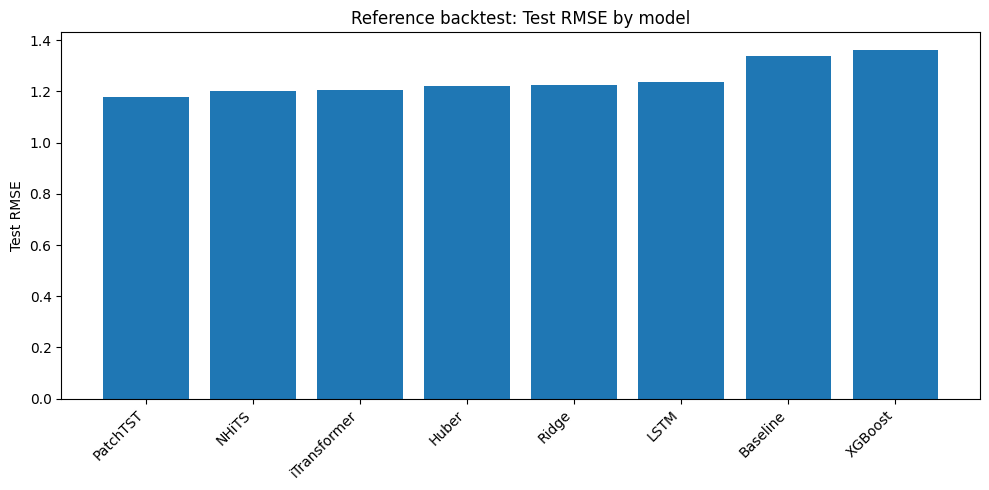

In [11]:
plot_df = overall_test.sort_values("RMSE").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test RMSE")
plt.title("Reference backtest: Test RMSE by model")
plt.tight_layout()
save_current_plot("01_reference_backtest_test_rmse_by_model.png")
plt.show()

### **Plot: monthly RMSE for the chosen final forecast**

Saved figure: experiment_notebooks\Experiment_Images_For_Case_Analysis\01_reference_backtest_monthly_rmse_final_forecast.png


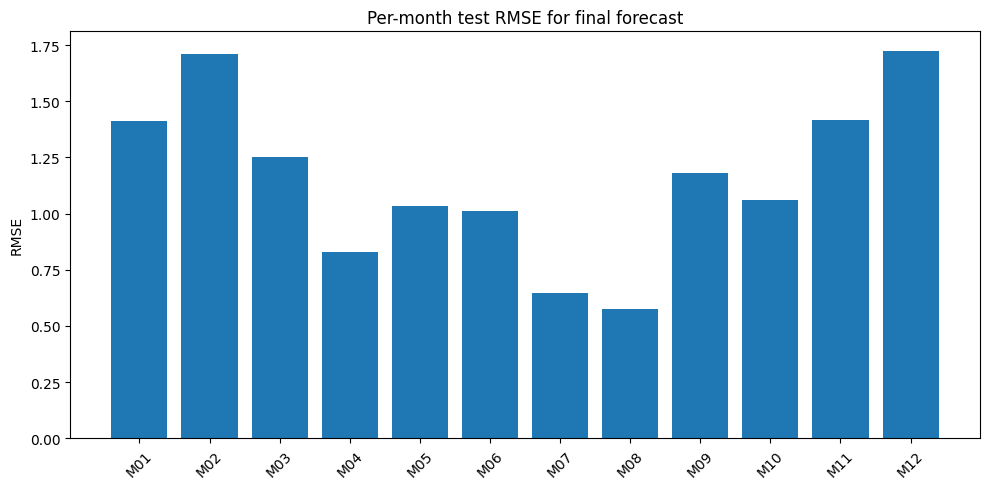

In [12]:
month_col = "RMSE" if "RMSE" in per_month_test.columns else per_month_test.columns[0]

plt.figure(figsize=(10, 5))
plt.bar(per_month_test.index.astype(str), per_month_test[month_col].values)
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Per-month test RMSE for final forecast")
plt.tight_layout()
save_current_plot("01_reference_backtest_monthly_rmse_final_forecast.png")
plt.show()

### **Find run artifcats path**


In [13]:
run_dir = Path(rr.run_id)
print("Run directory exists:", run_dir.exists())
print(run_dir)

artifact_files = sorted([p.name for p in run_dir.glob("*")]) if run_dir.exists() else []
artifact_files

Run directory exists: True
runs\official_backtest_20260824_034142_utc


['README.txt',
 'overall_test.csv',
 'overall_val.csv',
 'preds_test.csv',
 'preds_test_all.csv',
 'run_meta.json']

### **Load written run artifcats**

In [14]:
meta_path = run_dir / "run_meta.json"
preds_path = run_dir / "preds_test.csv"

with open(meta_path, "r", encoding="utf-8") as f:
    run_meta = json.load(f)

preds_test = (
    pd.read_csv(
        preds_path,
        parse_dates=["target_month"],
    )
    .set_index("target_month")
)

### **Forecast vs truth plot**

This plot is a visual check on timing, bias, and large misses. It complements the numeric metrics by showing where errors occur in the test period.

Saved figure: experiment_notebooks\Experiment_Images_For_Case_Analysis\01_reference_backtest_forecast_vs_truth.png


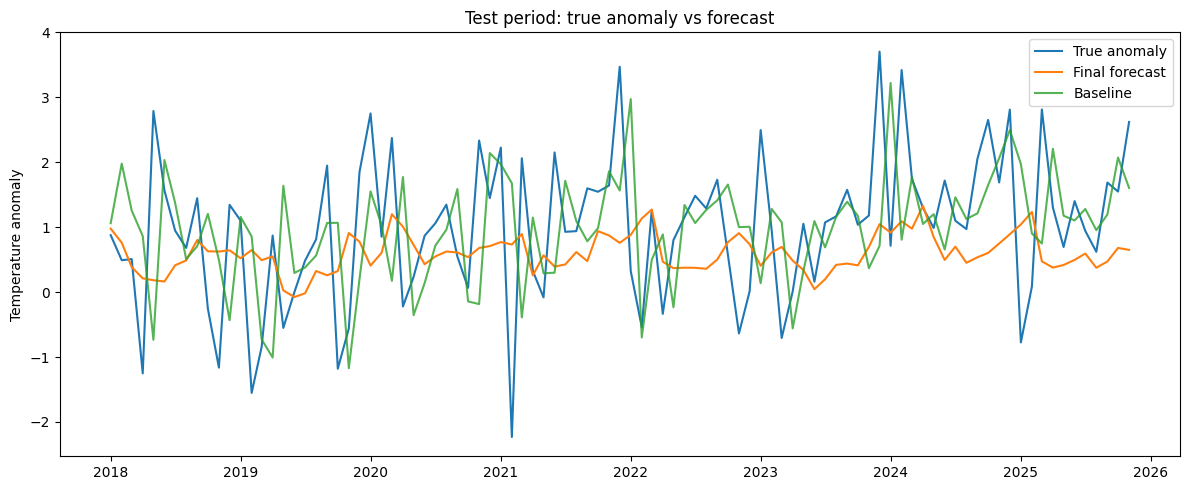

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(preds_test.index, preds_test["y_true"], label="True anomaly")
plt.plot(preds_test.index, preds_test["y_pred_final"], label="Final forecast")
plt.plot(preds_test.index, preds_test["y_pred_baseline"], label="Baseline", alpha=0.8)

plt.ylabel("Temperature anomaly")
plt.title("Test period: true anomaly vs forecast")
plt.legend()
plt.tight_layout()

save_current_plot("01_reference_backtest_forecast_vs_truth.png")
plt.show()

### **Biggest misses and biggest wins vs baseline**

These examples show where the selected model fails most severely and where it improves most over the baseline. They are useful for diagnosing seasonal or event-specific weaknesses.

In [16]:
out = preds_test.copy()
out["abs_err_baseline"] = np.abs(
    out["y_pred_baseline"] - out["y_true"]
)
out["baseline_minus_final_abs_err"] = (
    out["abs_err_baseline"] - out["abs_err_final"]
)

print("Largest final-model errors")
display(
    out.sort_values(
        "abs_err_final",
        ascending=False,
    ).head(10)
)

print(
    "/nLargest improvements over baseline "
    "(positive means final forecast better)"
)
display(
    out.sort_values(
        "baseline_minus_final_abs_err",
        ascending=False,
    ).head(10)
)

Largest final-model errors


,y_true,y_pred_final,y_pred_baseline,err_final,abs_err_final,month_key,abs_err_baseline,baseline_minus_final_abs_err
target_month,,,,,,,,
2021-02-01,-2.232194,0.732969,1.676692,2.965164,2.965164,M02,3.908887,0.943723
2021-12-01,3.471782,0.758518,1.564420,-2.713264,2.713264,M12,1.907362,-0.805902
2023-12-01,3.704452,1.046637,0.712920,-2.657815,2.657815,M12,2.991532,0.333717
2018-05-01,2.788942,0.183075,-0.734946,-2.605867,2.605867,M05,3.523888,0.918021
2020-01-01,2.751865,0.408258,1.550981,-2.343606,2.343606,M01,1.200884,-1.142723
2025-03-01,2.813317,0.473720,0.748257,-2.339597,2.339597,M03,2.065060,-0.274537
2024-02-01,3.420816,1.090403,0.807322,-2.330413,2.330413,M02,2.613493,0.283081
2019-02-01,-1.552926,0.647507,0.856689,2.200433,2.200433,M02,2.409614,0.209181
2023-01-01,2.495476,0.405632,0.137287,-2.089845,2.089845,M01,2.358190,0.268345


/nLargest improvements over baseline (positive means final forecast better)


,y_true,y_pred_final,y_pred_baseline,err_final,abs_err_final,month_key,abs_err_baseline,baseline_minus_final_abs_err
target_month,,,,,,,,
2024-01-01,0.713734,0.916725,3.220862,0.202991,0.202991,M01,2.507128,2.304137
2022-01-01,0.323525,0.881081,2.973330,0.557556,0.557556,M01,2.649805,2.092249
2019-05-01,-0.551543,0.025864,1.638175,0.577408,0.577408,M05,2.189719,1.612311
2019-04-01,0.870998,0.550169,-1.008201,-0.320829,0.320829,M04,1.879199,1.558370
2021-03-01,2.061316,0.894207,-0.390135,-1.167109,1.167109,M03,2.451452,1.284343
2018-02-01,0.490889,0.761035,1.978840,0.270146,0.270146,M02,1.487951,1.217805
2018-12-01,1.344630,0.643868,-0.432755,-0.700762,0.700762,M12,1.777385,1.076623
2020-03-01,2.372953,1.199221,0.173758,-1.173733,1.173733,M03,2.199195,1.025463
2020-09-01,0.546799,0.610615,1.587322,0.063816,0.063816,M09,1.040523,0.976707


---

# **Part 4: Conclusion**

### **Overall Takeaways**

* The first-pass machine learning benchmark improves upon the built-in 60/40 persistence and last-year baseline, showing that the models add value beyond a simple climate-memory forecast.
* Validation and test rankings are not perfectly consistent, suggesting that later notebooks should avoid treating a large model leaderboard as the primary research contribution.
* The transformer models consistently achieve the strongest performance, followed by the LSTM, while the traditional machine learning models perform the worst. Notably, all of the transformer models outperform the established 60/40 baseline by a substantial margin. Given the complexity of climate time series data, these results are not surprising, as transformers excel at capturing long-range dependencies and learning from high-dimensional data.

---